# NYC TLC Trip Record Data Report

## Introduction (Problem Description)

### Problem Statement

New York City taxi activity produces a very large volume of trip records, making it a valuable source for studying urban mobility, travel demand, and transportation patterns. However, the full TLC trip record collection is extremely large, so for this project we will focus only on the data from 2020. This reduces the scale to a manageable level while still preserving enough variation to support meaningful analysis.

The main challenges and questions in this setting include:

1. **Demand patterns**: How do taxi trips vary by hour, day of week, and month?
2. **Spatial behavior**: Which pickup and dropoff areas concentrate the highest trip activity?
3. **Trip efficiency**: How do trip duration, distance, and fare-related variables relate to each other?
4. **Operational variability**: Are there clear differences across time periods, vendors, or payment types?
5. **Data quality**: How can we handle missing values, outliers, and inconsistent records in a large-scale transport dataset?

### Project Objectives

This data engineering project aims to:

- **Collect and Profile**: Obtain NYC TLC trip records and profile the 2020 subset in detail
- **Clean and Prepare**: Handle missing values, invalid timestamps, duplicates, and extreme outliers
- **Explore and Analyze**: Study temporal, spatial, and fare-related patterns in the data
- **Engineer Features**: Create useful features such as trip duration, pickup hour, weekday, and trip speed
- **Generate Insights**: Extract actionable observations about mobility demand and trip behavior
- **Enable Prediction**: Prepare the dataset for forecasting or classification tasks related to taxi activity

### Scope and Methodology

This project follows a standard data engineering workflow:

1. Data acquisition from the NYC TLC trip record data portal
2. Exploratory data analysis and quality assessment
3. Data cleaning and preprocessing
4. Feature engineering and transformation
5. Statistical analysis and pattern discovery
6. Insight generation and recommendations

## Project Scope and Analysis Questions

### Focus of the Study

This project uses NYC TLC trip record data to study taxi mobility patterns in New York City, with the analysis restricted to 2020 because the full dataset is too large to process comfortably in this project. Working with one year still provides enough volume to analyze demand, spatial concentration, and trip behavior at city scale.

### Main Questions

- How did trip volume change across the year, across months, and across weekdays?
- Which pickup and dropoff locations were most active?
- How do trip distance, duration, and fare vary across different time periods?
- Are there patterns in passenger counts, payment types, or vendor behavior?
- What data cleaning steps are necessary before the data can be used reliably for analysis or modeling?

### Expected Outputs

- Cleaned and standardized trip records for the 2020 subset
- Temporal summaries by hour, day, week, and month
- Spatial summaries of pickup and dropoff activity
- Feature-engineered variables for downstream analytics
- A short set of findings to support transportation and mobility analysis

## Related Work

### Urban Mobility Analytics

Taxi trip data has been widely used to study movement patterns in cities, identify high-demand corridors, and understand how transportation demand changes over time. Previous work often combines temporal aggregation with spatial analysis to reveal mobility hotspots and travel regularities.

### Demand Forecasting and Trip Modeling

- **Time Series Analysis**: Historical trip counts are commonly modeled to forecast hourly, daily, or monthly demand
- **Spatial-Temporal Analysis**: Pickup and dropoff patterns are studied together to capture where and when demand concentrates
- **Regression and Classification**: Trip duration, fare amount, and trip characteristics are often used in predictive models

### Data Engineering for Transport Datasets

- **Open Mobility Data**: Public city transport datasets are frequently used for reproducible analysis and benchmarking
- **Large-Scale Cleaning**: Real-world trip data usually requires filtering invalid timestamps, removing impossible values, and handling missing fields
- **Feature Engineering**: Useful derived variables include trip duration, time-of-day bins, weekday indicators, and speed estimates

### Project Differentiation

This project focuses specifically on the 2020 NYC TLC trip record data and emphasizes:

- Data profiling at the year level instead of the full multi-year archive
- Cleaning and preparation of a very large but manageable subset
- Exploration of temporal and spatial trip patterns in a dense urban environment
- A foundation for later forecasting or mobility analysis tasks

## Dataset Profiling

### Dataset Overview

**Dataset**: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

**Source**: New York City Taxi and Limousine Commission (TLC)

**Scope Used in This Project**: Only the 2020 yellow taxi parquet files

**Dataset Characteristics**:
- Very large volume of trip records across New York City
- Trip-level information with pickup and dropoff timestamps and locations
- Fare, passenger, distance, and payment-related attributes
- Monthly parquet files that are compact enough for local profiling but still large enough to benefit from Spark or other big data tools when scaling beyond a laptop workflow

### Why Only 2020 and Why Parquet

The TLC archive contains a huge number of lines across multiple years and taxi types. To keep the project practical and the analysis focused, we use only the 2020 yellow taxi data. The parquet format is also more efficient than CSV for this workload, and the notebook reports the exact on-disk footprint of the files below.

### Main Variables of Interest

#### Temporal Information
- **Pickup Datetime**: When the trip started
- **Dropoff Datetime**: When the trip ended
- **Trip Duration**: Derived from pickup and dropoff timestamps
- **Hour / Day / Month**: Time features used for aggregation

#### Trip Information
- **Passenger Count**: Number of passengers recorded for the trip
- **Trip Distance**: Distance covered during the trip
- **Vendor ID**: Identifier for the taxi vendor
- **Rate Code**: Category describing the trip rate

#### Fare Information
- **Fare Amount**: Base trip fare
- **Extra / MTA Tax / Tip Amount / Tolls**: Additional fare components
- **Total Amount**: Final trip cost
- **Payment Type**: Method used to pay for the trip

#### Location Information
- **PULocationID**: Pickup location identifier
- **DOLocationID**: Dropoff location identifier
- **Pickup and Dropoff Zones**: Geographic areas used for spatial analysis

### Data Quality Considerations

**Strengths**:
- Very large sample size for robust aggregation
- Detailed temporal fields for demand analysis
- Fare and distance information suitable for behavioral analysis
- Location identifiers that support spatial grouping

**Potential Challenges**:
- Missing or invalid values in timestamps and numerical fields
- Outliers in trip distance, duration, fare, or passenger count
- Records with implausible zero or negative values
- High cardinality in location-based identifiers
- Need to standardize columns across monthly parquet files before analysis

### Analytical Opportunities

1. **Temporal Analysis**: Identify trip demand by hour, weekday, month, and season
2. **Spatial Analysis**: Discover the most active pickup and dropoff zones
3. **Trip Behavior Analysis**: Study relationships between distance, duration, and fare
4. **Payment Analysis**: Compare trip characteristics by payment type
5. **Predictive Modeling**: Build models for fare estimation or trip duration prediction
6. **Operational Planning**: Use the 2020 patterns to support transport demand understanding

In [ ]:
# Libraries
LOCAL = True

In [ ]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import numpy as np
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, to_date,
    avg,
    concat, lit
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

In [ ]:
# Spark Session

from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

In [ ]:
# Create taxi_df

import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType

# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),  # <-- AQUI ESTÁ A CORREÇÃO
    StructField("tpep_dropoff_datetime", TimestampType(), True), # <-- AQUI ESTÁ A CORREÇÃO
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)

Found parquet files: ['data/2020\\yellow_tripdata_2020-01.parquet', 'data/2020\\yellow_tripdata_2020-02.parquet', 'data/2020\\yellow_tripdata_2020-03.parquet', 'data/2020\\yellow_tripdata_2020-04.parquet', 'data/2020\\yellow_tripdata_2020-05.parquet', 'data/2020\\yellow_tripdata_2020-06.parquet']


C:\Users\nonof\AppData\Local\Temp\ipykernel_13044\1213687552.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)


Rows before: 24649092 after cleaning: 24598730

Column dtypes:
VendorID                          int64
pickup_datetime          datetime64[us]
dropoff_datetime         datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_min               float64
dtype: object

Missing value counts (top columns):
VendorID                        0
pickup_datetime                 0
dropoff_datetime  

Reference mappings loaded:
Unique zone names: 261
Unique boroughs: 7
Vendor labels: {1: 'Creative Mobile Technologies, LLC', 2: 'VeriFone Inc.'}
Rate codes: {1: 'Standard rate', 2: 'JFK', 3: 'Newark', 4: 'Nassau or Westchester', 5: 'Negotiated fare', 6: 'Group ride'}
Store and forward labels: {'Y': 'Store and forward trip', 'N': 'Not a store and forward trip'}
Payment labels: {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'}

Yellow taxi parquet storage footprint: 0.35 GB (357.2 MB) across 12 files
                               file  size_bytes   size_gb
0   yellow_tripdata_2020-01.parquet    93562858  0.087137
1   yellow_tripdata_2020-02.parquet    92134881  0.085807
2   yellow_tripdata_2020-03.parquet    44442590  0.041390
3   yellow_tripdata_2020-04.parquet     4442620  0.004138
4   yellow_tripdata_2020-05.parquet     6229864  0.005802
5   yellow_tripdata_2020-06.parquet     9505358  0.008853
6   yellow_tripdata_2020-07.parquet    13387778 

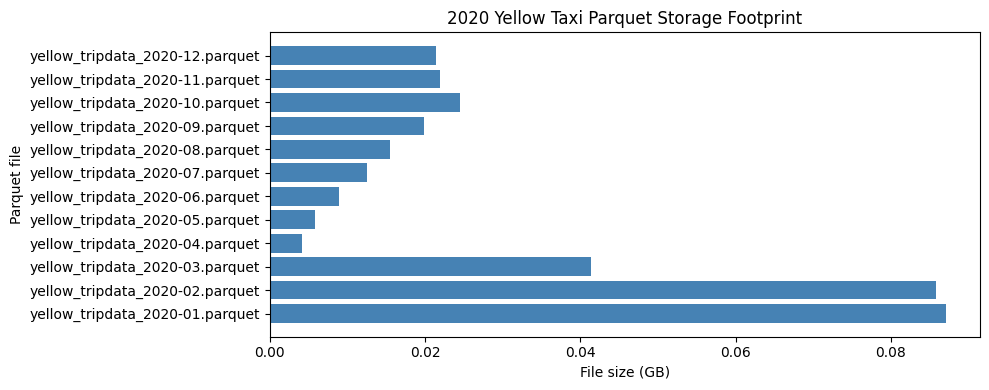

In [ ]:
# Reference mappings and storage footprint

import matplotlib.pyplot as plt
import seaborn as sns

# Reference mappings for 2020 yellow taxi data
vendor_lookup = {
    1: 'Creative Mobile Technologies, LLC',
    2: 'VeriFone Inc.'
}

ratecode_lookup = {
    1: 'Standard rate',
    2: 'JFK',
    3: 'Newark',
    4: 'Nassau or Westchester',
    5: 'Negotiated fare',
    6: 'Group ride'
}

store_and_fwd_lookup = {
    'Y': 'Store and forward trip',
    'N': 'Not a store and forward trip'
}

payment_lookup = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

# Convert zone_df to Pandas for mapping
zone_df_pd = zone_df.toPandas()
zone_lookup = zone_df_pd.set_index('LocationID')['Zone'].to_dict()
borough_lookup = zone_df_pd.set_index('LocationID')['Borough'].to_dict()

print('Reference mappings loaded:')
print('Unique zone names:', zone_df_pd['Zone'].nunique())
print('Unique boroughs:', zone_df_pd['Borough'].nunique())
print('Vendor labels:', vendor_lookup)
print('Rate codes:', ratecode_lookup)
print('Store and forward labels:', store_and_fwd_lookup)
print('Payment labels:', payment_lookup)

# Check parquet storage footprint for the yellow taxi files
if LOCAL:
  parquet_files = glob.glob(os.path.join(DATA_PATH, "*.parquet"))
  parquet_storage_data = []
  for path in parquet_files:
      parquet_storage_data.append({
          'file': os.path.basename(path),
          'size_bytes': os.path.getsize(path),
          'size_gb': os.path.getsize(path) / (1024 ** 3)
      })
  
  parquet_storage = pd.DataFrame(parquet_storage_data)
  
  if not parquet_storage.empty:
      parquet_storage = parquet_storage.sort_values('file')
      total_size_gb = parquet_storage['size_gb'].sum()
      total_size_mb = parquet_storage['size_bytes'].sum() / (1024 ** 2)
      print(f'\nYellow taxi parquet storage footprint: {total_size_gb:.2f} GB ({total_size_mb:,.1f} MB) across {len(parquet_storage)} files')
      print(parquet_storage)
      
      plt.figure(figsize=(10, 4))
      plt.barh(parquet_storage['file'], parquet_storage['size_gb'], color='steelblue')
      plt.xlabel('File size (GB)')
      plt.ylabel('Parquet file')
      plt.title('2020 Yellow Taxi Parquet Storage Footprint')
      plt.tight_layout()
      plt.show()

Dataset shape: (24598730, 28)
Date range: 2002-12-31 23:06:55 to 2021-06-10 10:10:48

Column profile (top 20 by missingness):
                               dtype  non_null   missing  missing_pct  \
airport_fee                  float64        21  24598709       100.00   
RateCodeName                  object  23822459    776271         3.16   
congestion_surcharge         float64  23823269    775461         3.15   
passenger_count              float64  23823269    775461         3.15   
RatecodeID                   float64  23823269    775461         3.15   
PaymentName                   object  23823269    775461         3.15   
store_and_fwd_flag            object  23823269    775461         3.15   
StoreAndFwdLabel              object  23823269    775461         3.15   
PULocationName                object  24433948    164782         0.67   
DOLocationName                object  24461571    137159         0.56   
DOLocationBorough             object  24541909     56821         0.23  

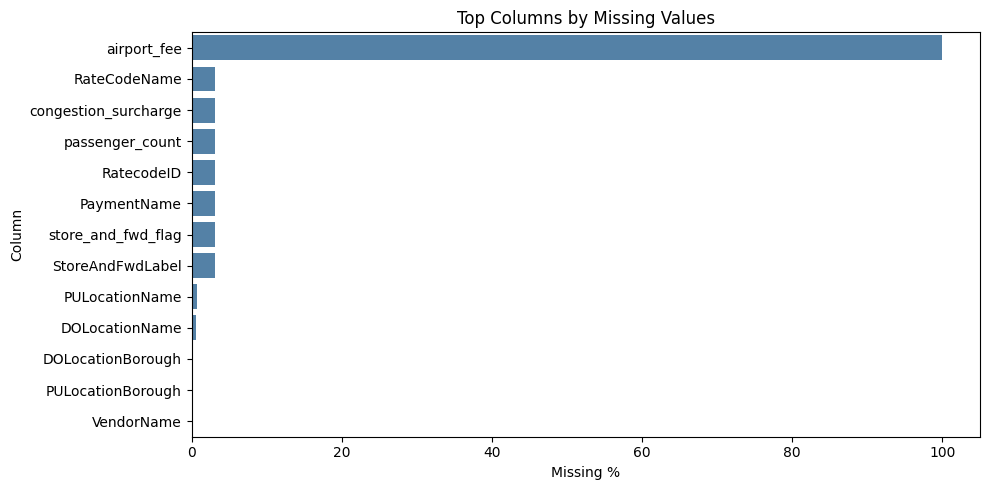

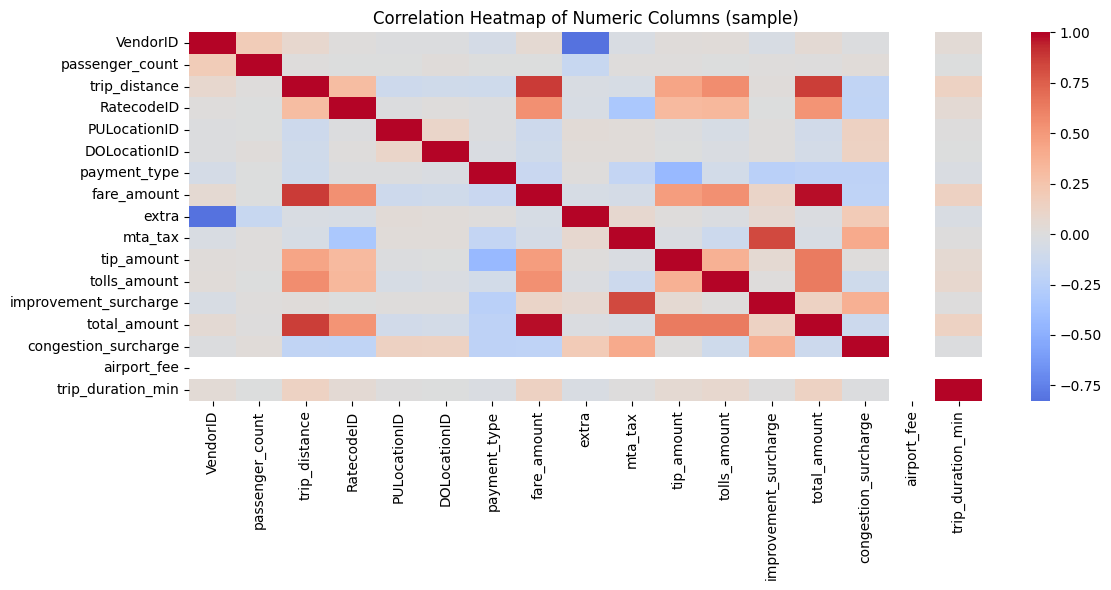

In [ ]:
# Dataset profiling: schema, missing values, and basic data quality

import numpy as np

print('Dataset shape:', (taxi_df.count(), len(taxi_df.columns)))

# Calculate min and max dates in Spark
date_range = taxi_df.select(
    col("tpep_pickup_datetime").cast("string").alias("min_date"),
    col("tpep_pickup_datetime").cast("string").alias("max_date")
).describe().toPandas()

print('Date range:', taxi_df.agg(
    {"tpep_pickup_datetime": "min", "tpep_dropoff_datetime": "max"}
).collect())

# Profile columns using Spark
profile_data = []
for col_name in taxi_df.columns:
    dtype = str(dict(taxi_df.dtypes)[col_name])
    non_null = taxi_df.filter(col(col_name).isNotNull()).count()
    missing = taxi_df.count() - non_null
    missing_pct = (missing / taxi_df.count() * 100)
    nunique = taxi_df.select(countDistinct(col_name)).collect()[0][0]
    
    profile_data.append({
        'column': col_name,
        'dtype': dtype,
        'non_null': non_null,
        'missing': missing,
        'missing_pct': round(missing_pct, 2),
        'nunique': nunique
    })

profile = pd.DataFrame(profile_data).sort_values(['missing_pct', 'nunique'], ascending=[False, False])

print('\nColumn profile (top 20 by missingness):')
print(profile.head(20))

# Identify numeric columns
numeric_cols = [col_name for col_name, dtype in taxi_df.dtypes if dtype in ['int', 'long', 'float', 'double']]
print('\nNumeric columns:')
print(numeric_cols)

# Data quality checks using Spark
total_rows = taxi_df.count()
quality_flags = {
    'negative_fare': taxi_df.filter(col('fare_amount') < 0).count(),
    'zero_or_negative_distance': taxi_df.filter(col('trip_distance') <= 0).count(),
    'missing_passenger_count': taxi_df.filter(col('passenger_count').isNull()).count(),
    'invalid_duration': taxi_df.filter(
        (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60 <= 0
    ).count(),
}

print('\nData quality flags:')
for name, value in quality_flags.items():
    print(f'{name}: {value:,}')

# Missing values visualization
missing_plot = profile[profile['missing'] > 0].head(15)
if not missing_plot.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_plot['missing_pct'], y=missing_plot['column'], color='steelblue')
    plt.xlabel('Missing %')
    plt.ylabel('Column')
    plt.title('Top Columns by Missing Values')
    plt.tight_layout()
    plt.show()

# Correlation heatmap (sample for performance)
if numeric_cols:
    sample_numeric = taxi_df.select(numeric_cols).sample(0.01).toPandas()
    plt.figure(figsize=(12, 6))
    sns.heatmap(sample_numeric.corr(numeric_only=True), cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numeric Columns (1% sample)')
    plt.tight_layout()
    plt.show()

In [ ]:
# Temporal Analysis: Trips by Hour, Day of Week, and Month

# Feature engineering in Spark
taxi_df_time = taxi_df.withColumn(
    "hour", hour("tpep_pickup_datetime")
).withColumn(
    "day_of_week", dayofweek("tpep_pickup_datetime")
).withColumn(
    "month", month("tpep_pickup_datetime")
).withColumn(
    "pickup_date", to_date("tpep_pickup_datetime")
)

# Trips by hour
trips_by_hour = taxi_df_time.groupBy("hour").count().orderBy("hour").toPandas()
trips_by_hour = trips_by_hour.set_index('hour')['count']

# Trips by weekday (1=Sunday, 7=Saturday in Spark dayofweek)
trips_by_weekday = taxi_df_time.groupBy("day_of_week").count().orderBy("day_of_week").toPandas()
day_names = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
trips_by_weekday['day_name'] = trips_by_weekday['day_of_week'].map(day_names)
trips_by_weekday = trips_by_weekday.set_index('day_name')['count']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trips_by_weekday = trips_by_weekday.reindex(day_order)

# Trips by month
trips_by_month = taxi_df_time.groupBy("month").count().orderBy("month").toPandas()
trips_by_month = trips_by_month.set_index('month')['count']

In [ ]:
# Spatial analysis using the official TLC zone lookup

# Top pickup and dropoff locations
pickup_location_counts = taxi_df.groupBy("PU_Zone").count().orderBy("count", ascending=False).toPandas()
pickup_location_counts = pd.Series(pickup_location_counts['count'].values, index=pickup_location_counts['PU_Zone'].values)

dropoff_location_counts = taxi_df.groupBy("DO_Zone").count().orderBy("count", ascending=False).toPandas()
dropoff_location_counts = pd.Series(dropoff_location_counts['count'].values, index=dropoff_location_counts['DO_Zone'].values)

# Create route names by concatenating pickup and dropoff zones
taxi_df_routes = taxi_df.withColumn(
    "route_named",
    concat(
        col("PU_Zone"),
        lit(" → "),
        col("DO_Zone")
    )
)

# Top routes (busiest zone pairs)
top_routes_named = taxi_df_routes.groupBy("route_named").count().orderBy("count", ascending=False).limit(10).toPandas()
top_routes_named = pd.Series(top_routes_named['count'].values, index=top_routes_named['route_named'].values)

# Top pickup and dropoff zones
top_n = 15
top_pickups_zones = pickup_location_counts.head(top_n)
top_dropoffs_zones = dropoff_location_counts.head(top_n)

In [ ]:
# Fare Analysis: Distribution and Relationships

# Filter non-zero tips
tips_nonzero = taxi_df.filter(col("tip_amount") > 0).select("tip_amount").toPandas()['tip_amount']

# Fare by payment type
payment_summary = taxi_df.groupBy("payment_type").agg(
    avg("fare_amount").alias("fare_mean"),
    ("fare_amount", "median"),
    spark_count("*").alias("count"),
    avg("tip_amount").alias("tip_mean"),
    avg("total_amount").alias("total_mean")
).toPandas()

# Correlation between distance and fare (from numeric columns)
corr_data = taxi_df.select("trip_distance", "fare_amount").dropna()
distance_fare_corr = corr_data.stat.corr("trip_distance", "fare_amount")

# Fare per mile analysis
df_valid_distance = taxi_df.filter(col("trip_distance") > 0).withColumn(
    "fare_per_mile",
    col("fare_amount") / col("trip_distance")
)

In [ ]:
# Trip Behavior Analysis: Distance, Duration, Passengers

# Add trip duration and other metrics
taxi_df_trips = taxi_df.withColumn(
    "duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "time_of_day",
    when(col("hour") < 6, "Night (0-6)")
    .when(col("hour") < 12, "Morning (6-12)")
    .when(col("hour") < 18, "Afternoon (12-18)")
    .otherwise("Evening (18-24)")
)

# Duration-distance correlation
duration_distance_corr = taxi_df_trips.select("duration_min", "trip_distance").dropna().stat.corr("duration_min", "trip_distance")

# Speed analysis
df_valid_trips = taxi_df_trips.filter(
    (col("trip_distance") > 0) & (col("duration_min") > 0)
).withColumn(
    "speed_mph",
    (col("trip_distance") / col("duration_min")) * 60
)

# Time of day analysis
time_analysis = taxi_df_trips.groupBy("time_of_day").agg(
    avg("trip_distance").alias("avg_distance"),
    avg("duration_min").alias("avg_duration"),
    avg("fare_amount").alias("avg_fare"),
    _sum("total_amount").alias("total_revenue"),
    spark_count("*").alias("trip_count")
).toPandas()

In [ ]:
# Vendor and Payment Type Analysis

# Add VendorName column using when/otherwise
taxi_df_vendor = taxi_df_trips.withColumn(
    "VendorName",
    when(col("VendorID") == 1, "Creative Mobile Technologies, LLC")
    .when(col("VendorID") == 2, "VeriFone Inc.")
    .otherwise("Unknown")
).withColumn(
    "PaymentName",
    when(col("payment_type") == 1, "Credit card")
    .when(col("payment_type") == 2, "Cash")
    .when(col("payment_type") == 3, "No charge")
    .when(col("payment_type") == 4, "Dispute")
    .when(col("payment_type") == 5, "Unknown")
    .when(col("payment_type") == 6, "Voided trip")
    .otherwise("Unknown")
).withColumn(
    "RateCodeName",
    when(col("RatecodeID") == 1, "Standard rate")
    .when(col("RatecodeID") == 2, "JFK")
    .when(col("RatecodeID") == 3, "Newark")
    .when(col("RatecodeID") == 4, "Nassau or Westchester")
    .when(col("RatecodeID") == 5, "Negotiated fare")
    .when(col("RatecodeID") == 6, "Group ride")
    .otherwise("Unknown")
).withColumn(
    "StoreAndFwdLabel",
    when(col("store_and_fwd_flag") == "Y", "Store and forward trip")
    .otherwise("Not a store and forward trip")
)

# Vendor summary
vendor_summary = taxi_df_vendor.groupBy("VendorName").agg(
    spark_count("*").alias("trip_count"),
    avg("trip_distance").alias("avg_distance"),
    avg("fare_amount").alias("avg_fare"),
    _sum("fare_amount").alias("total_fare"),
    _sum("total_amount").alias("total_amount"),
    avg("duration_min").alias("avg_duration")
).toPandas()

# Payment counts
payment_counts = taxi_df_vendor.groupBy("payment_type").count().orderBy("payment_type").toPandas()
payment_counts['payment_name'] = payment_counts['payment_type'].map(payment_lookup)
payment_counts = pd.Series(payment_counts['count'].values, index=payment_counts['payment_name'].values)

# Rate code counts
ratecode_counts = taxi_df_vendor.groupBy("RatecodeID").count().orderBy("RatecodeID").toPandas()
ratecode_counts['rate_name'] = ratecode_counts['RatecodeID'].map(ratecode_lookup)
ratecode_counts = pd.Series(ratecode_counts['count'].values, index=ratecode_counts['rate_name'].values)

# Store and forward counts
store_and_fwd_counts = taxi_df_vendor.groupBy("StoreAndFwdLabel").count().toPandas()
store_and_fwd_counts = pd.Series(store_and_fwd_counts['count'].values, index=store_and_fwd_counts['StoreAndFwdLabel'].values)

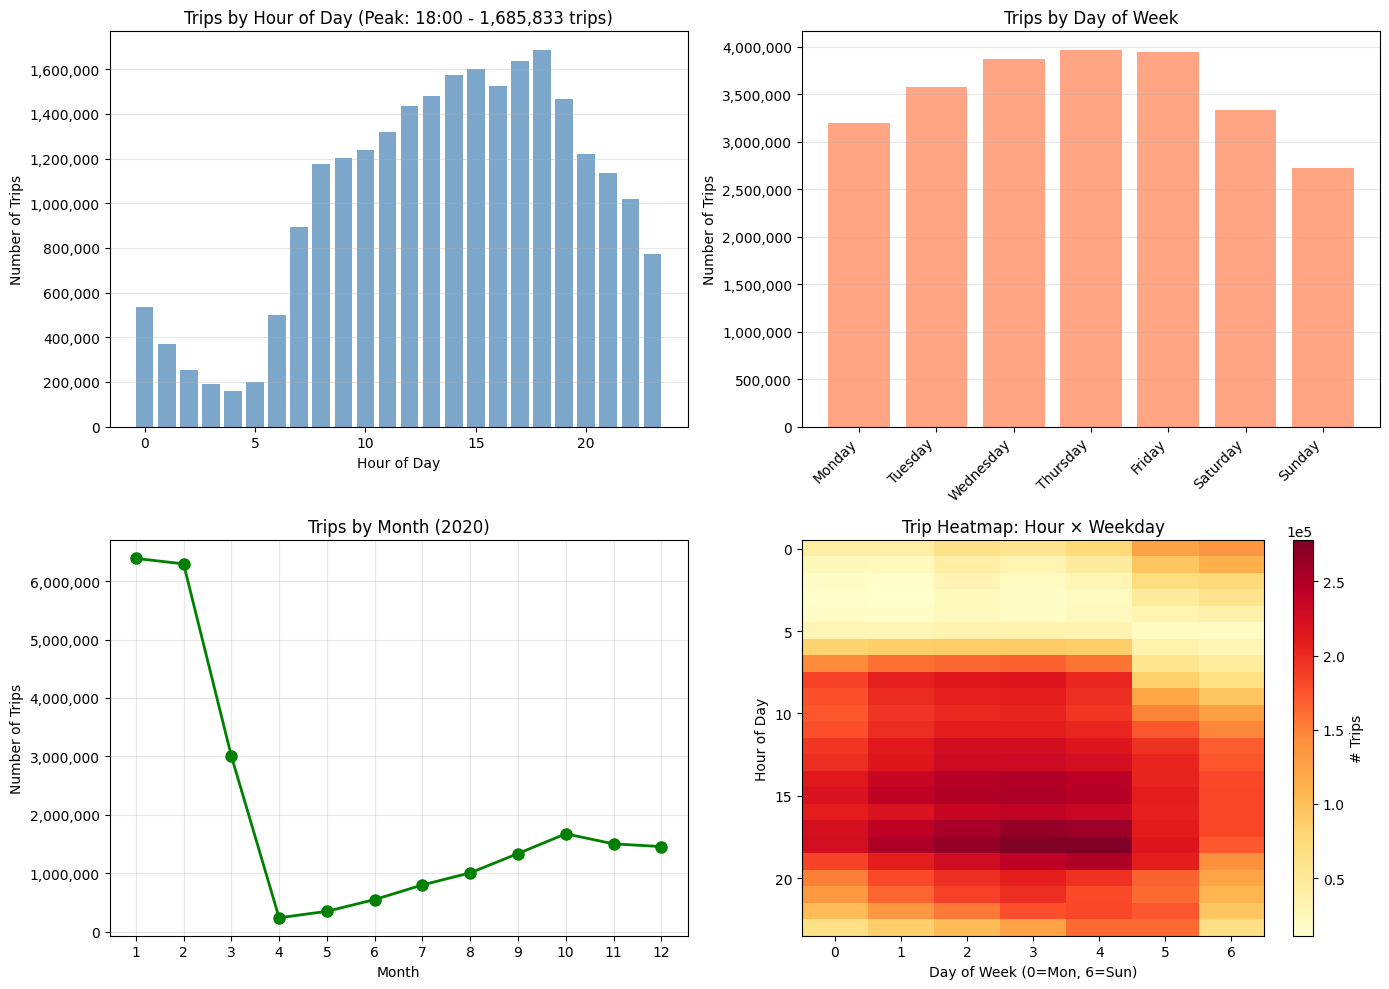

In [ ]:
# Visualization 1: Temporal Patterns (Hourly, Daily, Monthly)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly pattern
bars = axes[0, 0].bar(trips_by_hour.index, trips_by_hour.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Trips')
axes[0, 0].set_title(f'Trips by Hour of Day (Peak: {trips_by_hour.idxmax()}:00 - {trips_by_hour.max():,} trips)')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Daily pattern (weekday)
bars = axes[0, 1].bar(range(len(trips_by_weekday)), trips_by_weekday.values, color='coral', alpha=0.7)
axes[0, 1].set_xticks(range(len(trips_by_weekday)))
axes[0, 1].set_xticklabels(day_order, rotation=45, ha='right')
axes[0, 1].set_ylabel('Number of Trips')
axes[0, 1].set_title('Trips by Day of Week')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Monthly pattern
axes[1, 0].plot(trips_by_month.index, trips_by_month.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Trips')
axes[1, 0].set_title('Trips by Month (2020)')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Heatmap: Hour vs Weekday - create heatmap data from Spark
heatmap_data_spark = taxi_df_time.groupBy("day_of_week", "hour").count().toPandas()
heatmap_pivot = heatmap_data_spark.pivot(index="hour", columns="day_of_week", values="count").fillna(0)

im = axes[1, 1].imshow(heatmap_pivot, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_xlabel('Day of Week (1=Sun, 7=Sat)')
axes[1, 1].set_ylabel('Hour of Day')
axes[1, 1].set_title('Trip Heatmap: Hour × Weekday')
axes[1, 1].set_xticks(range(7))
cbar = plt.colorbar(im, ax=axes[1, 1], label='# Trips')
cbar.formatter.set_powerlimits((0, 0))

plt.tight_layout()
plt.show()

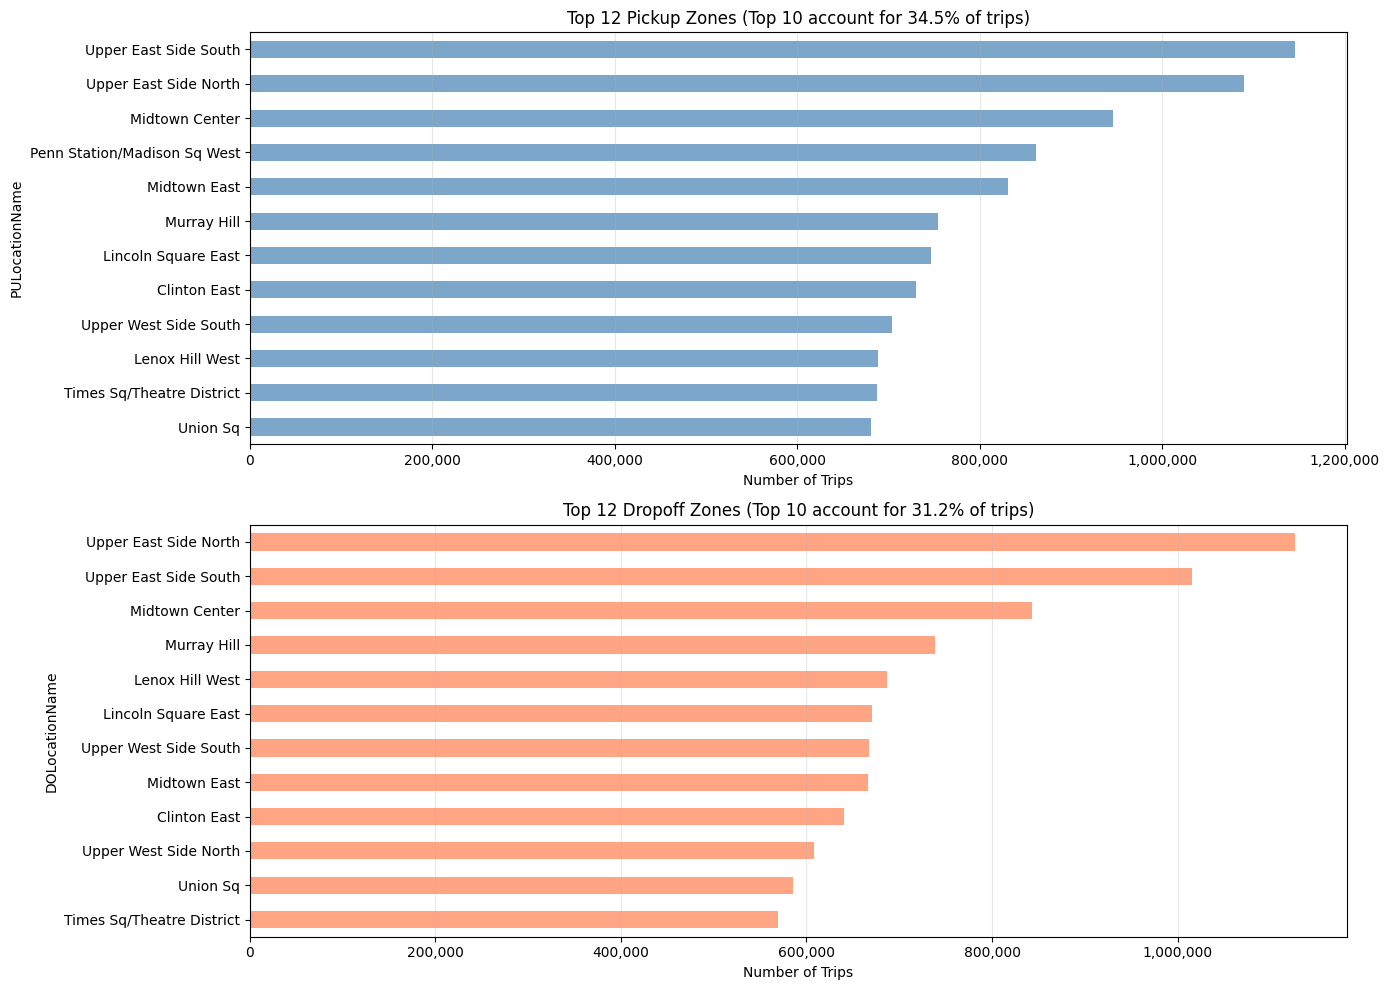

In [ ]:
# Visualization 2: Spatial Analysis - Top Locations and Routes
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top pickup location names
top_pickups_zones.head(12).plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Number of Trips')
axes[0].set_title(f'Top 12 Pickup Zones (Top 10 account for {top_pickups_zones.head(10).sum() / len(df) * 100:.1f}% of trips)')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Top dropoff location names
top_dropoffs_zones.head(12).plot(kind='barh', ax=axes[1], color='coral', alpha=0.7)
axes[1].set_xlabel('Number of Trips')
axes[1].set_title(f'Top 12 Dropoff Zones (Top 10 account for {top_dropoffs_zones.head(10).sum() / len(df) * 100:.1f}% of trips)')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

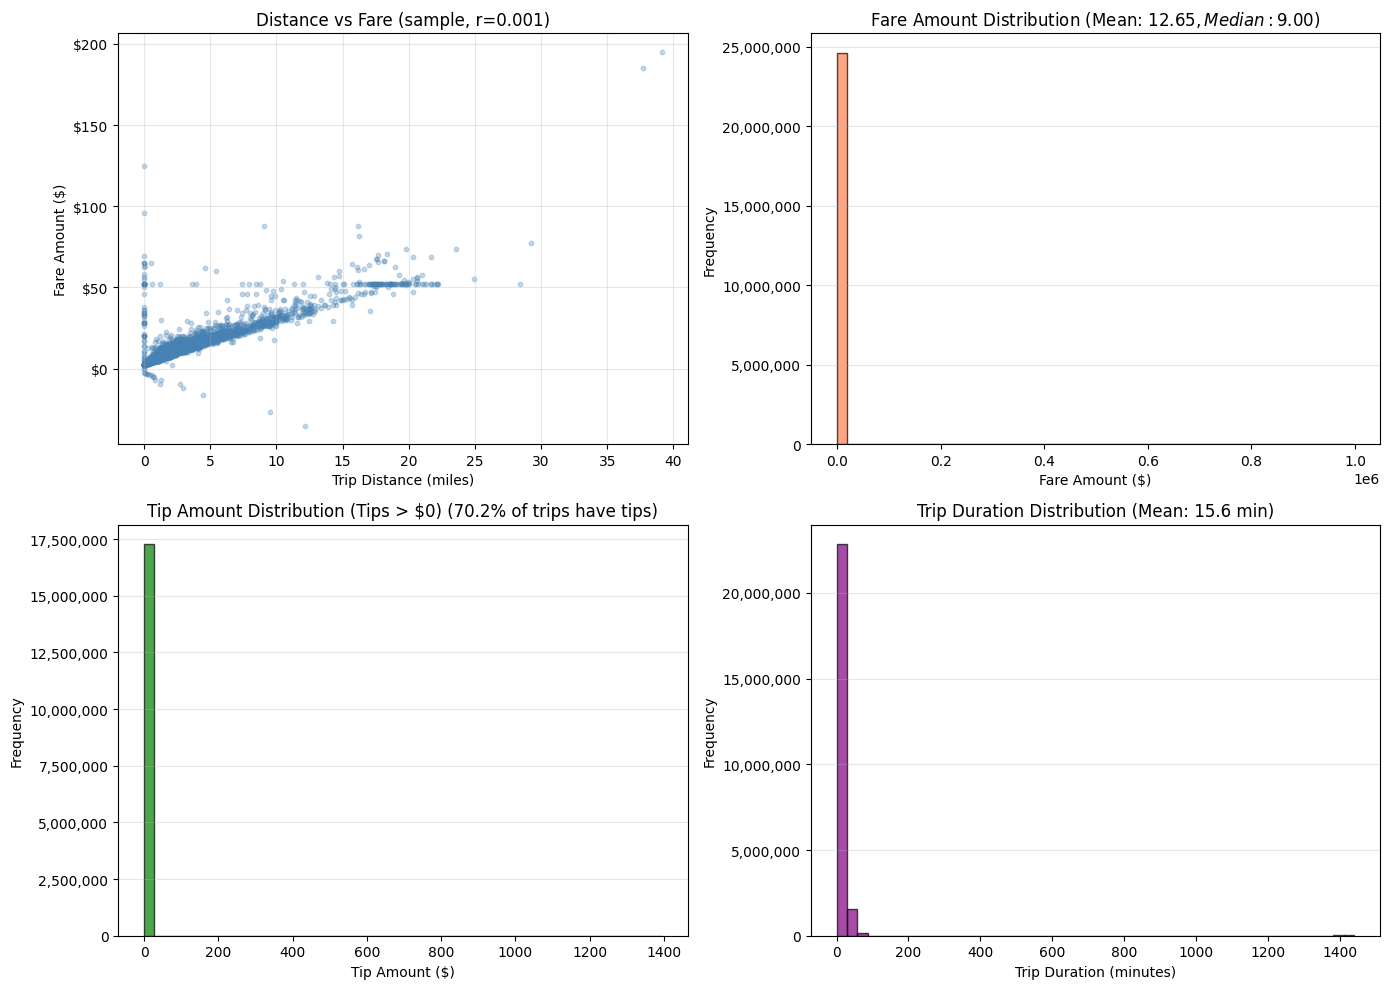

In [ ]:
# Visualization 3: Fare Analysis - Scatter and Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distance vs Fare scatter (sample for clarity)
sample_df = df.sample(min(5000, len(df)), random_state=42)
axes[0, 0].scatter(sample_df['trip_distance'], sample_df['fare_amount'], alpha=0.3, s=10, color='steelblue')
axes[0, 0].set_xlabel('Trip Distance (miles)')
axes[0, 0].set_ylabel('Fare Amount ($)')
axes[0, 0].set_title(f'Distance vs Fare (sample, r={distance_fare_corr:.3f})')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Fare distribution
axes[0, 1].hist(df['fare_amount'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Fare Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Fare Amount Distribution (Mean: ${df["fare_amount"].mean():.2f}, Median: ${df["fare_amount"].median():.2f})')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Tip distribution (non-zero)
axes[1, 0].hist(tips_nonzero, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Tip Amount ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Tip Amount Distribution (Tips > $0) ({len(tips_nonzero) / len(df) * 100:.1f}% of trips have tips)')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Trip duration distribution
axes[1, 1].hist(df['trip_duration_min'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Trip Duration (minutes)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Trip Duration Distribution (Mean: {df["trip_duration_min"].mean():.1f} min)')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

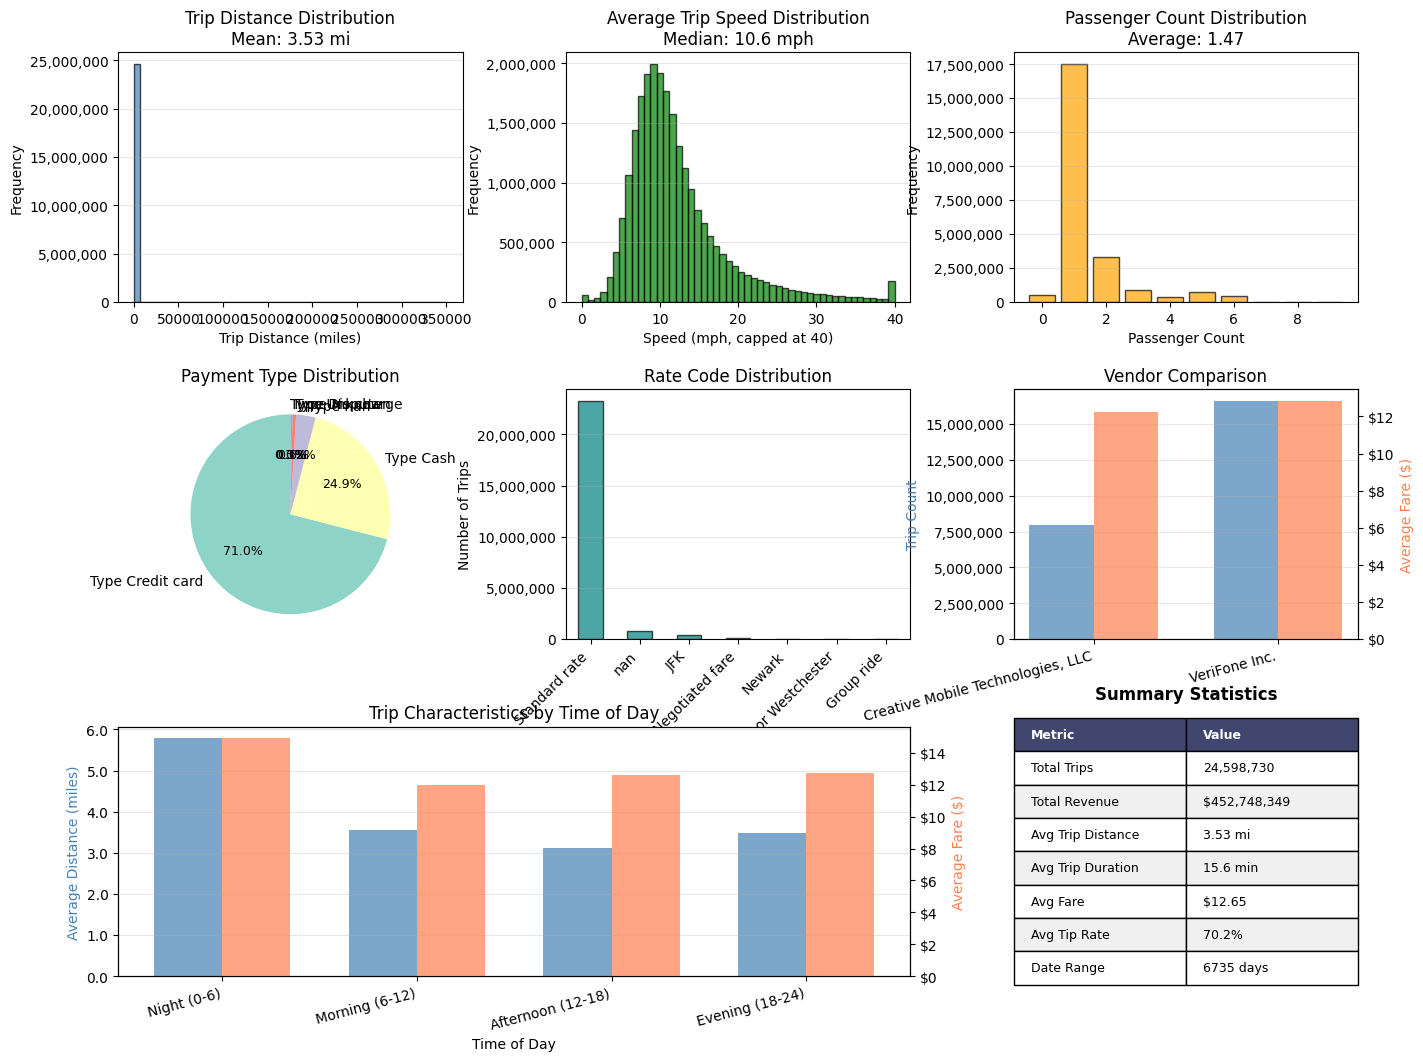

In [ ]:
# Visualization 4: Trip Characteristics, Payment Methods, and Summary Statistics
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Trip distance distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['trip_distance'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Trip Distance (miles)')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Trip Distance Distribution\nMean: {df["trip_distance"].mean():.2f} mi')
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Speed distribution (valid trips only)
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_valid_trips['speed_mph'].clip(0, 40), bins=50, color='green', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Speed (mph, capped at 40)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Average Trip Speed Distribution\nMedian: {df_valid_trips["speed_mph"].median():.1f} mph')
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Passenger count distribution
ax3 = fig.add_subplot(gs[0, 2])
passenger_counts = df['passenger_count'].value_counts().sort_index()
ax3.bar(passenger_counts.index, passenger_counts.values, color='orange', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Passenger Count')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Passenger Count Distribution\nAverage: {df["passenger_count"].mean():.2f}')
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Payment type breakdown (pie chart)
ax4 = fig.add_subplot(gs[1, 0])
colors_payment = plt.cm.Set3(range(len(payment_counts)))
wedges, texts, autotexts = ax4.pie(payment_counts.values, labels=[f'Type {i}' for i in payment_counts.index], 
               autopct='%1.1f%%', colors=colors_payment, startangle=90)
ax4.set_title('Payment Type Distribution')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)

# Rate code breakdown
ax5 = fig.add_subplot(gs[1, 1])
ratecode_counts.plot(kind='bar', ax=ax5, color='teal', alpha=0.7, edgecolor='black')
ax5.set_xlabel('Rate Code')
ax5.set_ylabel('Number of Trips')
ax5.set_title('Rate Code Distribution')
ax5.grid(axis='y', alpha=0.3)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Vendor comparison
ax6 = fig.add_subplot(gs[1, 2])
vendor_trips = df.groupby('VendorName').size()
vendor_avg_fare = df.groupby('VendorName')['fare_amount'].mean()
x_pos = range(len(vendor_trips))
width = 0.35
ax6_twin = ax6.twinx()

bars1 = ax6.bar([i - width/2 for i in x_pos], vendor_trips.values, width, label='Trip Count', color='steelblue', alpha=0.7)
bars2 = ax6_twin.bar([i + width/2 for i in x_pos], vendor_avg_fare.values, width, label='Avg Fare', color='coral', alpha=0.7)

ax6.set_xlabel('Vendor')
ax6.set_ylabel('Trip Count', color='steelblue')
ax6_twin.set_ylabel('Average Fare ($)', color='coral')
ax6.set_title('Vendor Comparison')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(vendor_trips.index, rotation=15, ha='right')
ax6.grid(axis='y', alpha=0.3)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax6_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Time of day analysis
ax7 = fig.add_subplot(gs[2, :2])
time_data = df.groupby('time_of_day', observed=True).agg({
    'trip_distance': 'mean',
    'fare_amount': 'mean'
}).round(2)
time_labels = time_data.index.astype(str)
x_pos = range(len(time_data))
width = 0.35

ax7_twin = ax7.twinx()
bars1 = ax7.bar([i - width/2 for i in x_pos], time_data['trip_distance'], width, label='Avg Distance', color='steelblue', alpha=0.7)
bars2 = ax7_twin.bar([i + width/2 for i in x_pos], time_data['fare_amount'], width, label='Avg Fare', color='coral', alpha=0.7)

ax7.set_xlabel('Time of Day')
ax7.set_ylabel('Average Distance (miles)', color='steelblue')
ax7_twin.set_ylabel('Average Fare ($)', color='coral')
ax7.set_title('Trip Characteristics by Time of Day')
ax7.set_xticks(x_pos)
ax7.set_xticklabels(time_labels, rotation=15, ha='right')
ax7.grid(axis='y', alpha=0.3)
ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
ax7_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Summary statistics table
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('tight')
ax8.axis('off')

summary_data = [
    ['Metric', 'Value'],
    ['Total Trips', f'{len(df):,}'],
    ['Total Revenue', f'${df["total_amount"].sum():,.0f}'],
    ['Avg Trip Distance', f'{df["trip_distance"].mean():.2f} mi'],
    ['Avg Trip Duration', f'{df["trip_duration_min"].mean():.1f} min'],
    ['Avg Fare', f'${df["fare_amount"].mean():.2f}'],
    ['Avg Tip Rate', f'{len(tips_nonzero) / len(df) * 100:.1f}%'],
    ['Date Range', f'{(df["pickup_datetime"].max() - df["pickup_datetime"].min()).days} days']
]

table = ax8.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Format header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax8.set_title('Summary Statistics', fontweight='bold', pad=20)

plt.show()

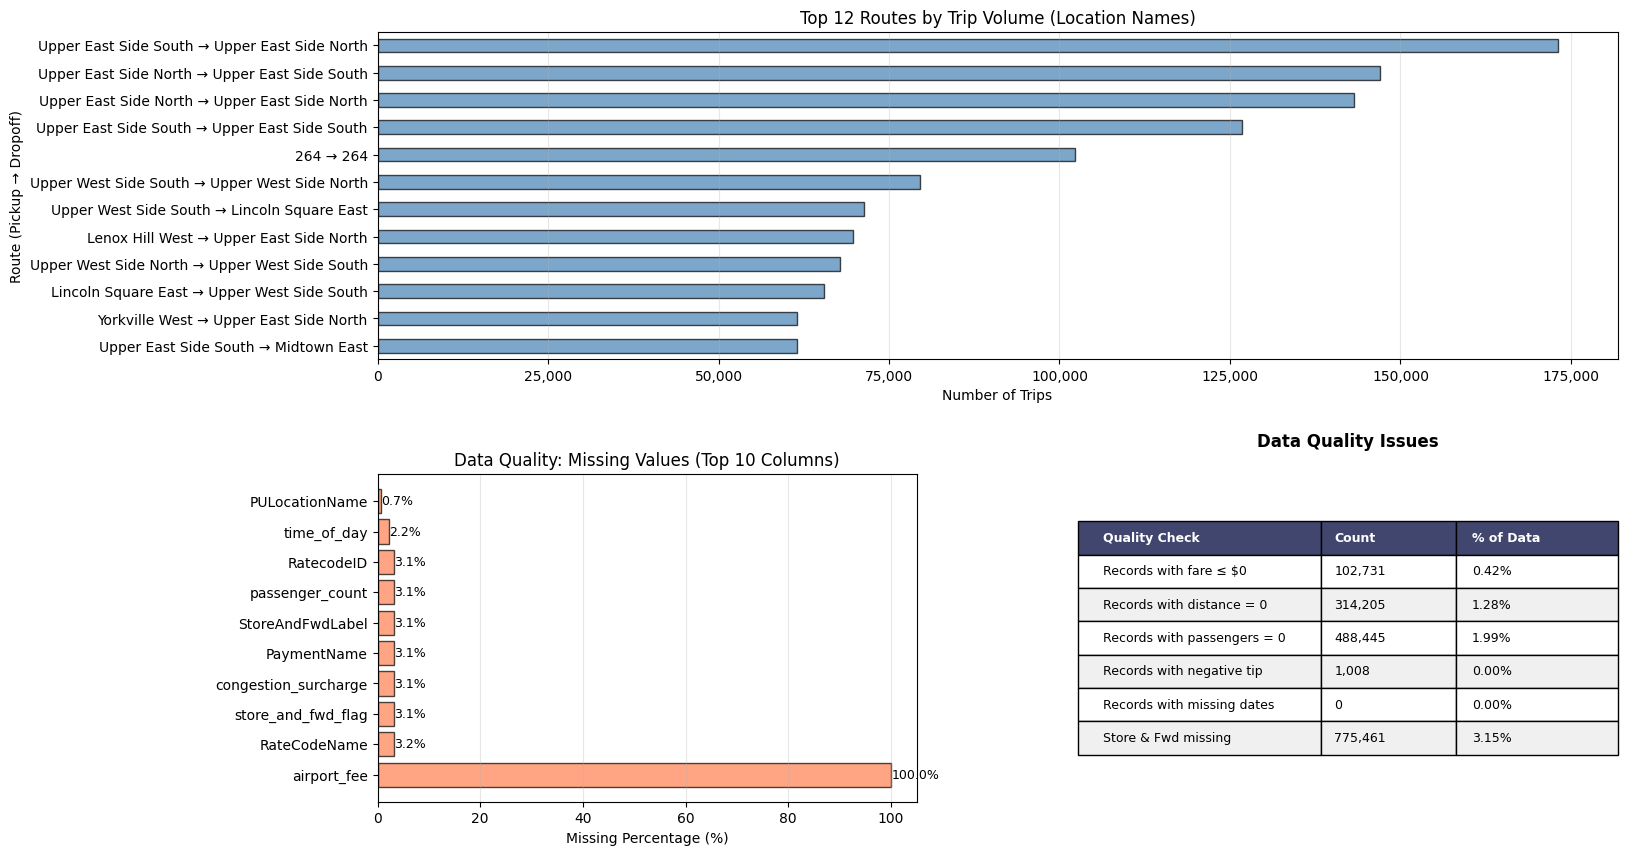

In [ ]:
# Visualization 5: Top Routes and Data Quality Metrics
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Top routes (zone to zone)
ax1 = fig.add_subplot(gs[0, :])
top_routes = df['route_named'].value_counts().head(12)
top_routes.plot(kind='barh', ax=ax1, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Number of Trips')
ax1.set_ylabel('Route (Pickup → Dropoff)')
ax1.set_title('Top 12 Routes by Trip Volume (Location Names)')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Data quality - missing values
ax2 = fig.add_subplot(gs[1, 0])
missing_data = df.isna().sum().sort_values(ascending=False).head(10)
missing_pct = (missing_data / len(df) * 100).round(2)
ax2.barh(range(len(missing_data)), missing_pct.values, color='coral', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(missing_data)))
ax2.set_yticklabels(missing_data.index)
ax2.set_xlabel('Missing Percentage (%)')
ax2.set_title('Data Quality: Missing Values (Top 10 Columns)')
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(missing_pct.values):
    if v > 0:
        ax2.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

# Data quality - anomalies
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

quality_issues = [
    ['Quality Check', 'Count', '% of Data'],
    ['Records with fare ≤ $0', f'{len(df[df["fare_amount"] <= 0]):,}', f'{len(df[df["fare_amount"] <= 0]) / len(df) * 100:.2f}%'],
    ['Records with distance = 0', f'{len(df[df["trip_distance"] == 0]):,}', f'{len(df[df["trip_distance"] == 0]) / len(df) * 100:.2f}%'],
    ['Records with passengers = 0', f'{len(df[df["passenger_count"] == 0]):,}', f'{len(df[df["passenger_count"] == 0]) / len(df) * 100:.2f}%'],
    ['Records with negative tip', f'{len(df[df["tip_amount"] < 0]):,}', f'{len(df[df["tip_amount"] < 0]) / len(df) * 100:.2f}%'],
    ['Records with missing dates', f'{df["pickup_datetime"].isna().sum():,}', f'{df["pickup_datetime"].isna().sum() / len(df) * 100:.2f}%'],
    ['Store & Fwd missing', f'{df["StoreAndFwdLabel"].isna().sum():,}', f'{df["StoreAndFwdLabel"].isna().sum() / len(df) * 100:.2f}%']
]

table = ax3.table(cellText=quality_issues, cellLoc='left', loc='center',
                  colWidths=[0.45, 0.25, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Format header row
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(quality_issues)):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax3.set_title('Data Quality Issues', fontweight='bold', pad=20)

plt.show()